   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        1       3  10728  3173     6393    1428              1165   
1        1       2  10117   927    11597     545              1251   
2        1       3  15438   854     2609    1300               873   
3        2       3   6642  6666    17266    2094               329   
4        2       3   1380  3586     4339     969             30237   

   Delicassen  Cluster  
0         580        1  
1         248        1  
2        3115        1  
3         889        1  
4        1996        2  

Medoid indices:
[124  14 154]

Cluster counts:
Cluster
0     78
1    301
2     61
Name: count, dtype: int64


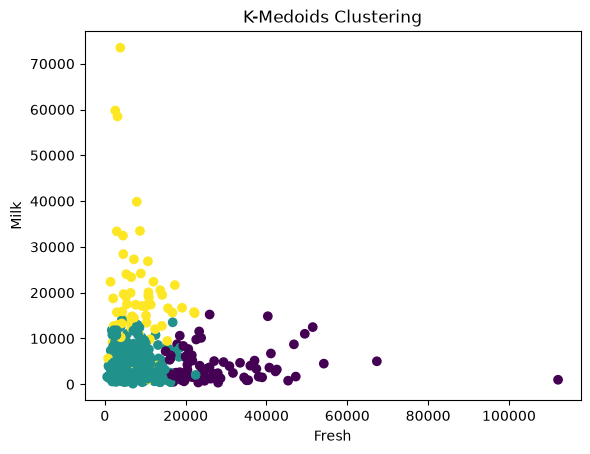

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from kmedoids import KMedoids

# Load dataset
data = pd.read_csv("Wholesale_Customers.csv")

# Select features for clustering
X = data[['Fresh', 'Milk', 'Grocery', 'Frozen',
          'Detergents_Paper', 'Delicassen']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create K-Medoids model
model = KMedoids(
    n_clusters=3,
    metric='euclidean',
    method='fasterpam',
    random_state=42
)

# Fit model
model.fit(X_scaled)

# Add cluster labels
data['Cluster'] = model.labels_

# Display result
print(data.head())

# Display medoids
print("\nMedoid indices:")
print(model.medoid_indices_)

# Display number of customers in each cluster
print("\nCluster counts:")
print(data['Cluster'].value_counts().sort_index())

# Plot using Fresh and Milk
plt.scatter(
    data['Fresh'],
    data['Milk'],
    c=data['Cluster']
)

plt.xlabel("Fresh")
plt.ylabel("Milk")
plt.title("K-Medoids Clustering")
plt.show()